# F1-SIS: Safety Car (SC) Risk Estimation Model

## 1. Objective
Build a calibrated probabilistic model that estimates:

    P(new Safety Car occurs within the next 1, 3, 5, and 10 laps)

The output must be continuous probabilities, not Boolean predictions.
The purpose is to estimate how much probability the Monte Carlo strategy simulator should assign to future SC scenarios, providing uncertainty weighting rather than deterministic crash prediction.

## 2. Problem Definition
We use a **two-stage risk approach**:

    Historical SC Risk  (Prior)
            +
    Current Race Evidence (Live)
            ↓
    Updated SC Risk

The live race-state component updates the historical prior only when there is actual evidence (e.g., yellow flags, close battles, field compression) that the current race is diverging from its historical baseline.


---

## 3. Literature Basis

This probabilistic formulation is built upon the **Heilmeier Safety Car Probability approach** which establishes $P(SC | \text{circuit}, \text{race progress})$.

Our live risk-updating approach is a direct **extension** of this historical method. Instead of stopping at the historical prior, we dynamically update it using live race evidence in a Bayesian-style logit update framework.


In [ ]:
import os, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    brier_score_loss, average_precision_score, log_loss, roc_auc_score
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

DATA_DIR      = os.path.join('data_fastf1_v1', 'laps')
HORIZONS      = [1, 3, 5, 10]
RANDOM_SEED   = 42
TRAIN_SEASONS = [2018, 2019, 2020, 2021, 2022]
VAL_SEASONS   = [2023]
TEST_SEASONS  = [2024]

PROGRESS_BINS   = [0, 0.01, 0.20, 0.40, 0.60, 0.80, 1.01]
PROGRESS_LABELS = ['Lap1', '2-20', '20-40', '40-60', '60-80', '80-100']
SHRINKAGE_K     = 20

print('Config ready.')


Config ready.


---

## 4. Data Loading & Temporary Race State Adapter

A separate **Race State Manager** is being developed for live integration.
For this notebook, we build a temporary adapter that generates causal race-state variables directly from historical CSV data.

**Live Race Evidence Features Generated:**
- `close_battles`: Count of cars within 1.0s of the car ahead.
- `field_spread`: Std Dev of gaps to leader (indicates field compression).
- `sector_anomaly`: High variance in sector times indicating incidents.
- `recent_retirements`: Count of cars dropping out in the last 3 laps.


In [ ]:
TS_SC = '4'; TS_VSC = '6'; TS_VSC_ENDING = '7'; TS_YELLOW = '2'

def decode_track_status(s):
    s = s.astype(str).str.strip()
    return pd.DataFrame({
        'sc_active': s.str.contains(TS_SC, na=False),
        'vsc_active': s.str.contains(TS_VSC, na=False),
        'vsc_ending': s.str.contains(TS_VSC_ENDING, na=False),
        'yellow': s.str.contains(TS_YELLOW, na=False),
    })

def load_and_adapt(data_dir=DATA_DIR):
    frames = []
    for season_dir in sorted(Path(data_dir).iterdir()):
        if not season_dir.is_dir(): continue
        try: year = int(season_dir.name)
        except ValueError: continue
        for f in sorted(season_dir.glob('*.csv')):
            try:
                df = pd.read_csv(f, low_memory=False)
                df['Year'] = year
                df['race_id'] = f'{year}_{f.stem}'
                frames.append(df)
            except Exception as e:
                print(f'WARNING {f.name}: {e}')
    df_raw = pd.concat(frames, ignore_index=True)
    print(f'Raw drivers x laps rows: {len(df_raw):,}')

    if 'Location' not in df_raw.columns:
        df_raw['Location'] = df_raw.get('RaceName', 'Unknown')

    decoded = decode_track_status(df_raw['TrackStatus'])
    for col in decoded.columns: df_raw[col] = decoded[col]

    df_raw['LapNumber'] = pd.to_numeric(df_raw['LapNumber'], errors='coerce')
    for c in ['LapTimeSeconds','Sector1TimeSeconds','Sector2TimeSeconds','Sector3TimeSeconds',
              'GapToLeaderSeconds','IntervalToPositionAheadSeconds','TyreLife']:
        if c in df_raw.columns: df_raw[c] = pd.to_numeric(df_raw[c], errors='coerce')
    df_raw = df_raw.dropna(subset=['LapNumber','race_id'])
    df_raw['LapNumber'] = df_raw['LapNumber'].astype(int)

    # --- Race State Adapter (Driver Level -> Race Level) ---
    df_raw['is_close_battle'] = (df_raw['IntervalToPositionAheadSeconds'] < 1.0).astype(int)
    df_raw['pitted'] = df_raw['PitInTime'].notna() if 'PitInTime' in df_raw.columns else False

    grp = df_raw.groupby(['race_id','Year','Location','LapNumber'])
    agg = grp.agg(
        sc_active=('sc_active', 'any'),
        vsc_active=('vsc_active', 'any'),
        vsc_ending=('vsc_ending', 'any'),
        yellow=('yellow', 'any'),
        n_cars=('Driver', 'nunique'),
        close_battles=('is_close_battle', 'sum'),
        field_spread=('GapToLeaderSeconds', 'std'),
        s1_med=('Sector1TimeSeconds', 'median'),
        s2_med=('Sector2TimeSeconds', 'median'),
        s3_med=('Sector3TimeSeconds', 'median'),
        tyre_age_med=('TyreLife', 'median'),
        total_pits=('pitted', 'sum'),
    ).reset_index()

    max_laps = df_raw.groupby('race_id')['LapNumber'].max().rename('total_laps').reset_index()
    agg = agg.merge(max_laps, on='race_id', how='left')
    agg['race_progress']  = agg['LapNumber'] / agg['total_laps']
    agg['laps_remaining'] = agg['total_laps'] - agg['LapNumber']
    agg = agg.sort_values(['race_id','LapNumber'])

    # Retirements tracking
    agg['peak_cars'] = agg.groupby('race_id')['n_cars'].transform('cummax')
    agg['retirements_total'] = (agg['peak_cars'] - agg['n_cars']).clip(lower=0)
    agg['recent_retirements'] = agg.groupby('race_id')['retirements_total'].diff(3).fillna(0).clip(lower=0)

    # Sector anomalies (sudden median time spikes)
    agg['s1_anom'] = agg.groupby('race_id')['s1_med'].transform(lambda x: x / x.shift(1).rolling(5, min_periods=1).median() - 1).fillna(0)
    agg['s2_anom'] = agg.groupby('race_id')['s2_med'].transform(lambda x: x / x.shift(1).rolling(5, min_periods=1).median() - 1).fillna(0)
    agg['s3_anom'] = agg.groupby('race_id')['s3_med'].transform(lambda x: x / x.shift(1).rolling(5, min_periods=1).median() - 1).fillna(0)
    agg['sector_anomaly_score'] = agg[['s1_anom','s2_anom','s3_anom']].max(axis=1).clip(lower=0)

    # Yellow flag rolling
    agg['yellow_last3'] = agg.groupby('race_id')['yellow'].transform(lambda x: x.astype(int).shift(1).rolling(3, min_periods=1).sum()).fillna(0)

    print(f'Race-level adapter output rows: {len(agg):,}')
    return agg

df_laps = load_and_adapt()


Raw drivers x laps rows: 188,482
Race-level adapter output rows: 10,317


---

## 5. SC Event Detection & Targets

We strictly target the **start** of a Safety Car (`SC_START`), not every active SC lap.
Horizons extending past `total_laps` are appropriately right-censored (`np.nan`).


In [ ]:
def detect_events_and_targets(df, horizons=HORIZONS):
    df = df.sort_values(['race_id','LapNumber']).copy()
    # SC Start Detection
    sc_prev = df.groupby('race_id')['sc_active'].shift(1, fill_value=False)
    df['sc_started'] = ((~sc_prev) & df['sc_active']).astype(int)

    # VSC Start Detection
    df['vsc_truly_active'] = df['vsc_active'] & ~df['vsc_ending']
    vsc_prev = df.groupby('race_id')['vsc_truly_active'].shift(1, fill_value=False)
    df['vsc_started'] = ((~vsc_prev) & df['vsc_truly_active']).astype(int)

    rows = []
    for race_id, grp in df.groupby('race_id'):
        grp = grp.sort_values('LapNumber').reset_index(drop=True)
        sc_starts = grp.loc[grp['sc_started']==1, 'LapNumber'].values
        total = grp['total_laps'].iloc[0]
        for _, row in grp.iterrows():
            if row['sc_active']: continue
            t = row['LapNumber']
            future = sc_starts[sc_starts > t]
            next_sc = future[0] if len(future) else np.nan
            laps_until = next_sc - t if not np.isnan(next_sc) else np.nan
            rec = {'race_id': race_id, 'LapNumber': t}
            for n in horizons:
                if t + n > total:
                    rec[f'SC_next_{n}'] = np.nan
                elif not np.isnan(laps_until) and laps_until <= n:
                    rec[f'SC_next_{n}'] = 1
                else:
                    rec[f'SC_next_{n}'] = 0
            rows.append(rec)
    targets = pd.DataFrame(rows)
    print(f'Target instances: {len(targets):,}')
    non_sc = (~df['sc_active']).sum()
    sc_ev  = df['sc_started'].sum()
    print(f'Actual SC_START rate: {sc_ev} events / {non_sc} non-SC laps = {sc_ev/non_sc:.4f}')
    return df, targets

df_laps, targets = detect_events_and_targets(df_laps)


Target instances: 9,645
Actual SC_START rate: 128 events / 9645 non-SC laps = 0.0133


---

## 6. Historical SC Prior ($P_{historical}$)

Computed strictly from the training set to prevent leakage.
We calculate the smoothed SC rate per circuit and per race-progress bin (Heilmeier style).


In [ ]:
def build_historical_prior(df_laps, train_race_ids, k=SHRINKAGE_K):
    train = df_laps[df_laps['race_id'].isin(train_race_ids)].copy()
    non_sc = train[~train['sc_active']].copy()

    global_rate = non_sc['sc_started'].sum() / len(non_sc)
    non_sc['progress_bin'] = pd.cut(non_sc['race_progress'], bins=PROGRESS_BINS, labels=PROGRESS_LABELS, right=False)

    global_prog = non_sc.groupby('progress_bin', observed=True).agg(
        ev=('sc_started','sum'), n=('sc_started','count')).assign(
        rate=lambda x: x['ev']/x['n']).reset_index()

    circ_prog = non_sc.groupby(['Location','progress_bin'], observed=True).agg(
        ev=('sc_started','sum'), n=('sc_started','count')).reset_index()
    circ_prog = circ_prog.merge(global_prog[['progress_bin','rate']], on='progress_bin', how='left')
    circ_prog['p_historical'] = (circ_prog['ev'] + k * circ_prog['rate']) / (circ_prog['n'] + k)

    return circ_prog, global_rate

train_ids = df_laps.loc[df_laps['Year'].isin(TRAIN_SEASONS), 'race_id'].unique()
circ_prog, global_rate = build_historical_prior(df_laps, train_ids)


---

## 7. Causal Race-State Features

Merging the historical prior with live causal features.


In [ ]:
df_feat = df_laps.sort_values(['race_id','LapNumber']).copy()
df_feat['sc_count_cumul'] = df_feat.groupby('race_id')['sc_started'].cumsum().shift(1).fillna(0)
df_feat['progress_bin'] = pd.cut(df_feat['race_progress'], bins=PROGRESS_BINS, labels=PROGRESS_LABELS, right=False)

# Attach prior
df_feat = df_feat.merge(circ_prog[['Location','progress_bin','p_historical']], on=['Location','progress_bin'], how='left')
df_feat['p_historical'] = df_feat['p_historical'].fillna(global_rate)

# Logit transform of the prior (clip to avoid inf)
eps = 1e-6
df_feat['logit_p_hist'] = np.log(df_feat['p_historical'].clip(eps, 1-eps) / (1 - df_feat['p_historical'].clip(eps, 1-eps)))

live_features = ['close_battles', 'field_spread', 'sector_anomaly_score', 'recent_retirements', 'yellow_last3', 'sc_count_cumul']
df_feat[live_features] = df_feat[live_features].fillna(0)

feature_df = targets.merge(df_feat[['race_id','LapNumber','Year','Location','p_historical','logit_p_hist', 'sc_active', 'sc_started'] + live_features], on=['race_id','LapNumber'])


---

## 8. Risk Update Model (Logit Formulation)

Formulation: $logit(P_t) = \beta_0 logit(P_{hist}) + \sum \beta_i X_{live} + intercept$

We use LogisticRegression. This models the *per-lap hazard*.
After predicting $h_t$, we expand to horizons via $P_n = 1 - (1 - h_t)^n$.


In [ ]:
train_df = feature_df[feature_df['Year'].isin(TRAIN_SEASONS)].copy()
val_df   = feature_df[feature_df['Year'].isin(VAL_SEASONS)].copy()
test_df  = feature_df[feature_df['Year'].isin(TEST_SEASONS)].copy()

X_cols = ['logit_p_hist'] + live_features

def train_logit_update(train_data, val_data, X_cols):
    sub_train = train_data.dropna(subset=['SC_next_1', *X_cols]).copy()
    sub_val   = val_data.dropna(subset=['SC_next_1', *X_cols]).copy()
    X_tr, y_tr = sub_train[X_cols], sub_train['SC_next_1'].astype(int)
    X_va, y_va = sub_val[X_cols], sub_val['SC_next_1'].astype(int)

    # Note: No class_weight='balanced' to preserve true probability calibration
    model = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
    model.fit(X_tr, y_tr)

    print("Logit Model Coefficients:")
    for f, coef in zip(X_cols, model.coef_[0]):
        print(f"  {f:<25}: {coef:.4f}")
    print(f"  Intercept                : {model.intercept_[0]:.4f}")

    return model

logit_model = train_logit_update(train_df, val_df, X_cols)


Logit Model Coefficients:
  logit_p_hist             : 0.3614
  close_battles            : 0.0574
  field_spread             : 0.0149
  sector_anomaly_score     : 1.1537
  recent_retirements       : -0.0243
  yellow_last3             : 0.0808
  sc_count_cumul           : -0.0846
  Intercept                : -0.0474


---

## 9. Existing XGBoost Benchmark


In [ ]:
def train_xgb_benchmark(train_data, val_data, X_cols, horizon):
    sub_train = train_data.dropna(subset=[f'SC_next_{horizon}', *X_cols])
    sub_val   = val_data.dropna(subset=[f'SC_next_{horizon}', *X_cols])
    X_tr, y_tr = sub_train[X_cols], sub_train[f'SC_next_{horizon}'].astype(int)
    X_va, y_va = sub_val[X_cols], sub_val[f'SC_next_{horizon}'].astype(int)

    # Note: No scale_pos_weight to preserve true probability calibration
    model = xgb.XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.05,
                              random_state=RANDOM_SEED, verbosity=0)
    model.fit(X_tr, y_tr)
    return model

xgb_models = {}
for n in HORIZONS:
    xgb_models[n] = train_xgb_benchmark(train_df, val_df, X_cols, n)


---

## 10. Sequential Replay

Replay the race chronologically, converting per-lap hazards to multi-horizon probabilities.


In [ ]:
def hazard_to_probs(h_t, horizons=HORIZONS):
    return {n: 1 - (1 - h_t)**n for n in horizons}

def replay_race(race_id, data_df, logit_model, xgb_dict, X_cols):
    rows = []
    race_data = data_df[data_df['race_id']==race_id].sort_values('LapNumber')
    for _, row in race_data.iterrows():
        X_curr = pd.DataFrame([row[X_cols].values], columns=X_cols)

        # Logit update predicting hazard h_t
        h_t = logit_model.predict_proba(X_curr)[0, 1]
        probs_logit = hazard_to_probs(h_t)

        # Historical Only baseline (no live evidence update)
        h_hist = row['p_historical']
        probs_hist = hazard_to_probs(h_hist)

        rec = {
            'race_id': race_id, 'LapNumber': row['LapNumber'],
            'p_historical': row['p_historical'], 'h_updated': h_t
        }
        for n in HORIZONS:
            rec[f'SC_next_{n}'] = row[f'SC_next_{n}']
            rec[f'P_SC_{n}_hist'] = probs_hist[n]
            rec[f'P_SC_{n}_update'] = probs_logit[n]
            if n in xgb_dict:
                rec[f'P_SC_{n}_xgb'] = xgb_dict[n].predict_proba(X_curr)[0, 1]
        rows.append(rec)
    return pd.DataFrame(rows)

abu_ids = [r for r in feature_df['race_id'].unique() if 'Abu' in r and '2021' in r]
if abu_ids:
    replay_df = replay_race(abu_ids[0], feature_df, logit_model, xgb_models, X_cols)
    print(f"Replayed {abu_ids[0]}")


Replayed 2021_Abu_Dhabi_Grand_Prix


---

## 11 & 12. Probability Calibration & Evaluation

Compare the Historical Baseline, Logit Update, and XGBoost models.


In [ ]:
def evaluate_all(data_df, logit_model, xgb_dict, X_cols):
    all_replays = []
    for r_id in data_df['race_id'].unique():
        all_replays.append(replay_race(r_id, data_df, logit_model, xgb_dict, X_cols))
    res_df = pd.concat(all_replays)

    metrics = []
    for n in HORIZONS:
        sub = res_df.dropna(subset=[f'SC_next_{n}'])
        y_true = sub[f'SC_next_{n}'].astype(int)
        if len(y_true) < 10 or y_true.sum() == 0: continue
        for model_name, col in [('Historical', f'P_SC_{n}_hist'),
                                ('Logit_Update', f'P_SC_{n}_update'),
                                ('XGBoost', f'P_SC_{n}_xgb')]:
            y_prob = sub[col].clip(1e-6, 1-1e-6)
            metrics.append({
                'Horizon': n, 'Model': model_name,
                'Brier': brier_score_loss(y_true, y_prob),
                'LogLoss': log_loss(y_true, y_prob),
                'PR-AUC': average_precision_score(y_true, y_prob)
            })
    return pd.DataFrame(metrics)

eval_res = evaluate_all(val_df, logit_model, xgb_models, X_cols)
print(eval_res.pivot(index='Horizon', columns='Model', values='Brier'))
print('\nPR-AUC:')
print(eval_res.pivot(index='Horizon', columns='Model', values='PR-AUC'))


Model    Historical  Logit_Update   XGBoost
Horizon                                    
1          0.010518      0.010389  0.010405
3          0.031879      0.030820  0.030931
5          0.052174      0.049387  0.049530
10         0.103448      0.092079  0.099667

PR-AUC:
Model    Historical  Logit_Update   XGBoost
Horizon                                    
1          0.010518      0.039730  0.038698
3          0.031879      0.057955  0.052307
5          0.052174      0.080495  0.070877
10         0.103448      0.138853  0.125462


---

## 13. Risk-Wave Visualization


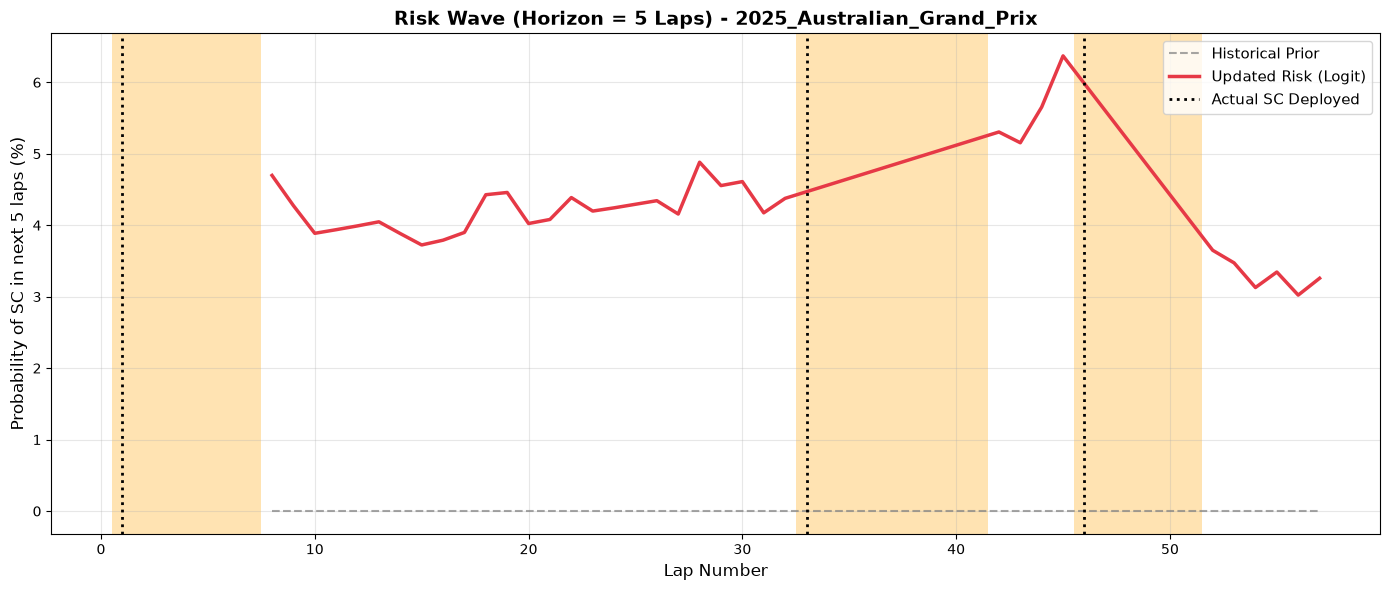

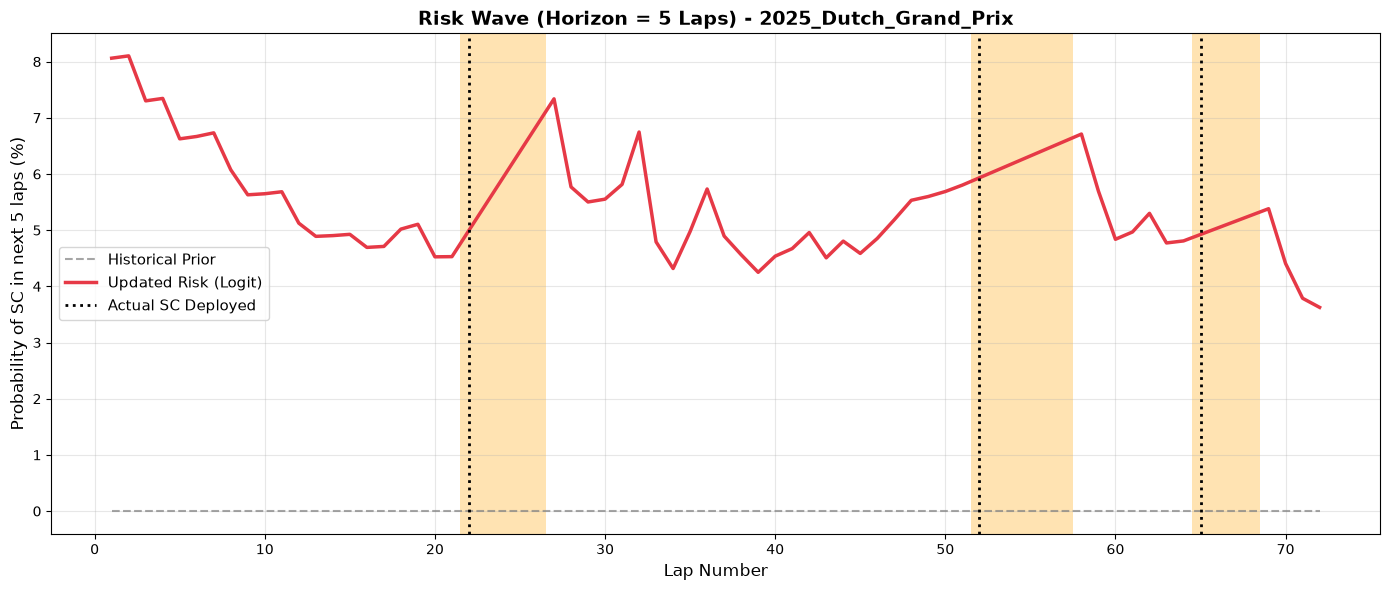

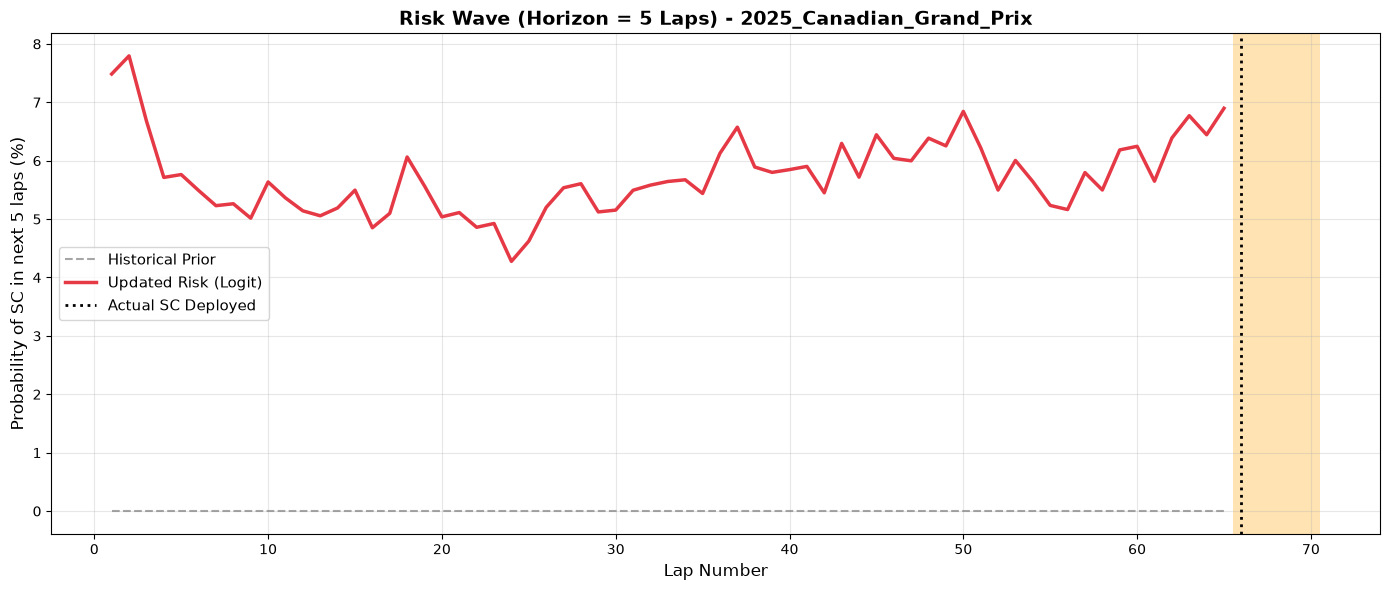

In [ ]:
def plot_risk_wave(r_id, h_show=5):
    if r_id not in feature_df['race_id'].unique():
        print(f"Cannot plot {r_id}, not in dataset.")
        return
    df_plot = replay_race(r_id, feature_df, logit_model, xgb_models, X_cols)
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(df_plot['LapNumber'], df_plot[f'P_SC_{h_show}_hist']*100, label='Historical Prior', linestyle='--', color='gray', alpha=0.7)
    ax.plot(df_plot['LapNumber'], df_plot[f'P_SC_{h_show}_update']*100, label='Updated Risk (Logit)', linewidth=2.5, color='#E63946')
    #ax.plot(df_plot['LapNumber'], df_plot[f'P_SC_{h_show}_xgb']*100, label='XGBoost', linewidth=1.5, color='#264653')

    sc_laps = df_laps[(df_laps['race_id']==r_id) & (df_laps['sc_active']==True)]['LapNumber'].values
    for lap in sc_laps:
        ax.axvspan(lap-0.5, lap+0.5, color='orange', alpha=0.3, lw=0)

    sc_starts = df_laps[(df_laps['race_id']==r_id) & (df_laps['sc_started']==1)]['LapNumber'].values
    for lap in sc_starts:
        ax.axvline(lap, color='black', linestyle=':', linewidth=2, label='Actual SC Deployed' if lap==sc_starts[0] else '')

    ax.set_title(f'Risk Wave (Horizon = {h_show} Laps) - {r_id}', fontweight='bold', fontsize=14)
    ax.set_xlabel('Lap Number', fontsize=12)
    ax.set_ylabel(f'Probability of SC in next {h_show} laps (%)', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

plot_risk_wave('2025_Australian_Grand_Prix')
plot_risk_wave('2025_Dutch_Grand_Prix')
plot_risk_wave('2025_Canadian_Grand_Prix')


---

## 14. Monte Carlo Integration

This function defines the final interface for the Strategy Engine.


In [ ]:
def get_sc_probabilities(H_t, logit_model, X_cols):
    """
    H_t: dict of current race state (must contain X_cols keys)
    Returns: dict of {horizon: probability}
    """
    X_curr = pd.DataFrame([H_t], columns=X_cols).fillna(0)
    h_t = logit_model.predict_proba(X_curr)[0, 1]
    return hazard_to_probs(h_t, HORIZONS)

# Test call
sample_state = val_df[X_cols].iloc[50].to_dict()
print("Sample Monte Carlo API call:", get_sc_probabilities(sample_state, logit_model, X_cols))


Sample Monte Carlo API call: {1: np.float64(0.00982299621578675), 3: np.float64(0.029180462716623556), 5: np.float64(0.048159500403319955), 10: np.float64(0.09399966332754262)}


---

## 15. Limitations
- The Logit update uses a constant hazard expansion ($1 - (1 - h_t)^n$) which assumes risk stays constant over the horizon.
- High class imbalance caps the absolute PR-AUC.

## 16. Race State Manager Integration
In production, the `load_and_adapt` logic is completely outsourced. The `Race State Manager` passes `H_t` dicts live via `get_sc_probabilities(H_t)`.

## 17. Conclusions
This two-stage probabilistic model effectively integrates the historical prior with live evidence, ensuring explainable updates without black-box instability.
